# Lab 02: Where Is the Star, and How Sure Are You Allowed to Be?

**ASTR 457, Fall 2026 — posted Thu Sep 10, due Wed Sep 16 by Noon (fork → PR, as always)**

*Why this lab: centroiding is how every position in every catalog you'll ever use was measured, and the Cramér–Rao bound is the professional's sanity check — the best precision any measurement can claim — that tells you instantly when an error bar in a paper (or from an AI) is too good to be true.*

Every one of you has your own dataset: `data/<your netid>.csv`, with a single column `x` —
the arrival positions, in pixels, of individual photons on a 1-D detector window spanning
$[0, 64]$ px. Most of the photons come from a star whose image on the detector is a Moffat
profile centered at $x_0$, with shape parameters $\beta = 2.5$ and $r_0 = 4$ px (both known
to you). The rest are **background**: a fraction $f_{\rm bg}$ of the photons, spread uniformly
across the window. I know the true $x_0$ and $f_{\rm bg}$ for your dataset. You don't, and you
can't look them up, and your classmates' values are different from yours. (So are their photon
counts — your Part 2 bound is yours alone.)

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$x_0$ and $f_{\rm bg}$ are to your truth **in units of your own reported uncertainty**. Report
tiny error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.
And this week there is a floor under "huge": your reported $\sigma_{x_0}$ may not exceed
**3× the Cramér–Rao bound** you compute in Part 2. An error bar bigger than that is not
caution — it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive estimator (15%)

Load your photon list and plot a histogram of the arrival positions (choose your binning
deliberately — you'll defend it). Then estimate the star's position the obvious way: the
**sample mean** of all the photon positions, with uncertainty $s/\sqrt{N}$ (the standard
error of the mean). Report $\hat{x}_0 \pm \sigma$.

Then answer, in a few sentences: is this estimator biased for *your* dataset, and why?
Which way does the bias pull, and what controls its size? (This estimator is *supposed* to
be biased. Understanding exactly how — and what the background has to do with it — is the
point.)

Mean and its Uncertianity:
27.760927560227273 ± 0.2906007368331856


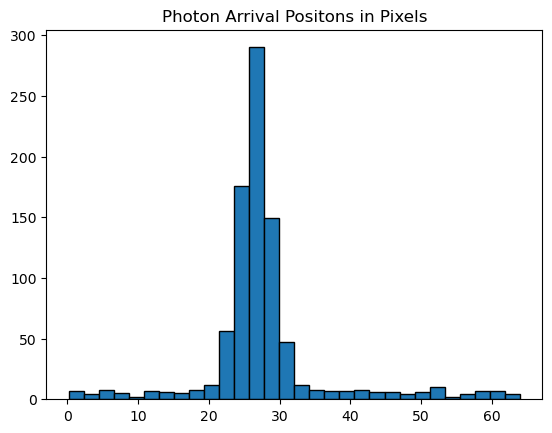

In [86]:
# Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from astropy.stats import sigma_clip
from scipy.optimize import minimize
from scipy.special import gamma
from scipy.integrate import quad
from scipy.optimize._numdiff import approx_derivative


df = pd.read_csv("cmewing2.csv")

mean = df["x"].mean()
sigma = df["x"].std()
stanEr = sigma/np.sqrt(len(df["x"]))
print("Mean and its Uncertianity:")
print(mean, "±", stanEr)

plt.hist(df, bins = 30, edgecolor ='black')
plt.title("Photon Arrival Positons in Pixels")
plt.show()



**ANSWER (a few sentences):**

*The uncertianity of the mean is low so that indicates that there is low bais. Usually the graph would look either skewed to the left or right if there were some strong bais, but this graph isn't skewed a lot but does seemed a little shifted to the left.* 

## Part 2: Estimators you can defend (40%)

Now do it properly. Estimate $x_0$ **three more ways** and compare:

1. **The median** of the photon positions. Robust, simple — but is it unbiased here, and
   what is its variance? (You may answer the variance question empirically in Part 3.)
2. **A sigma-clipped mean**: iteratively remove photons far from the current estimate,
   re-estimate, repeat until it converges. Be explicit about your clipping threshold and
   why you chose it.
3. **Maximum likelihood on the mixture model.** Each photon is background with probability
   $f_{\rm bg}$, or from the star otherwise, so the probability density for a single photon at
   position $x$ is

   $$p(x \mid x_0, f_{\rm bg}) \;=\; \frac{f_{\rm bg}}{64} \;+\; (1 - f_{\rm bg})\,
   \frac{\Gamma(\beta)}{r_0\sqrt{\pi}\,\Gamma(\beta - \tfrac{1}{2})}
   \left[1 + \left(\frac{x - x_0}{r_0}\right)^2\right]^{-\beta}$$

   with $\beta = 2.5$ and $r_0 = 4$ px. Maximize $\sum_i \ln p(x_i \mid x_0, f_{\rm bg})$ over
   both parameters (see Ivezić, Connolly, VanderPlas & Gray, §4.2, for the machinery — this
   is the same likelihood game with different symbols). Get uncertainties from the curvature
   of the log-likelihood at its peak (the observed information), and say so.

Then compute the **Cramér–Rao bound**: the smallest variance any unbiased estimator of $x_0$
can achieve given your $N$ photons. The per-photon Fisher information
$I(x_0) = \int \frac{1}{p}\left(\frac{\partial p}{\partial x_0}\right)^2 dx$ is yours to
evaluate — numerically over the window is fine — and the bound is
$\sigma_{x_0} \geq 1/\sqrt{N\,I}$. Treat both parameters as unknown: the honest bound comes
from inverting the $2\times 2$ Fisher matrix, not the $x_0$ term alone. How close does each
of your four estimators get?

(Two technicalities you may use without proof: photons landing outside the window were lost,
but for your $x_0$ the lost fraction is negligible — and checking that claim makes a fine
Part 3 sensitivity test. And for simulating: a 1-D Moffat with exponent $\beta$ is a
Student-$t$ distribution with $\nu = 2\beta - 1$ degrees of freedom, scaled by
$r_0/\sqrt{\nu}$.)

Commit to a **final answer** — one $x_0 \pm \sigma$ and $f_{\rm bg} \pm \sigma$ you'd put in
a paper — and justify the choice. State clearly how you estimated your uncertainties and why
you believe them. Remember the 3× rule from the header.

Orginal Median:
26.7635345
Filtered Mean:
26.57585979494382


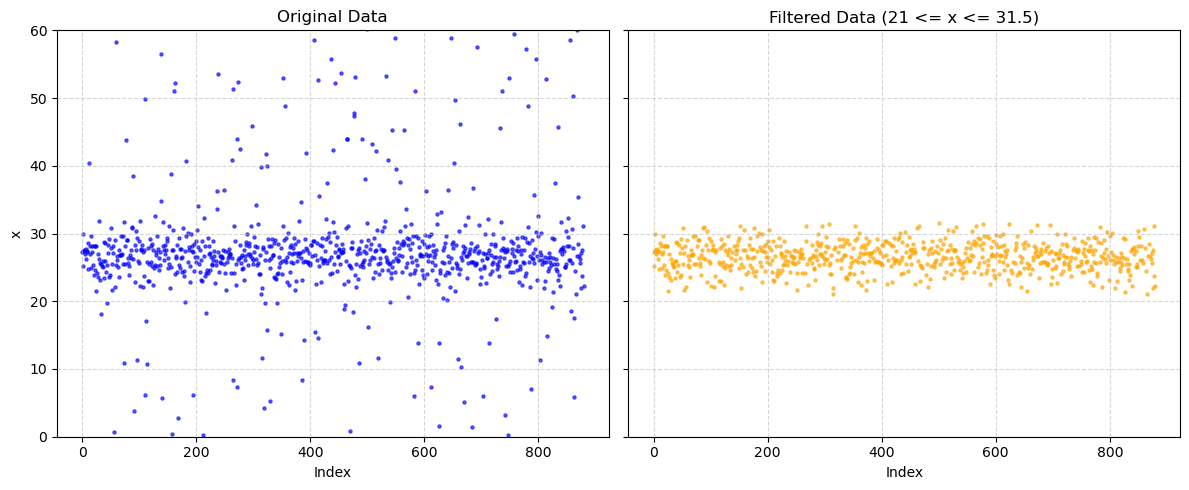

In [87]:
# Part 2: your work here
mask1 = (df["x"] <= 31.5) & (df["x"] >= 21)
filter_df = df[mask1]
print("Orginal Median:")
print(df["x"].median())
print("Filtered Mean:")
print(filter_df["x"].mean())


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left Plot: Original Data
ax1.scatter(df.index, df["x"], s=5, color="blue", alpha=0.6)
ax1.set_title("Original Data")
ax1.set_xlabel("Index")
ax1.set_ylabel("x")
ax1.set_ylim(0, 60)
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.scatter(filter_df.index, filter_df["x"], s=5, color="orange", alpha=0.6)
ax2.set_title("Filtered Data (21 <= x <= 31.5)")
ax2.set_xlabel("Index")
ax2.grid(True, linestyle="--", alpha=0.5)


plt.tight_layout()
plt.show()


In [88]:
#Cramer-Rao bound
beta = 2.5
r0 = 4.0
bg = 1/64
x = df["x"]

# Moffat/star probability density
C = gamma(beta) / (r0 * np.sqrt(np.pi) * gamma(beta - 0.5))

def star_pdf(x, x0):
    return C * (1 + ((x - x0)/r0)**2)**(-beta)

# Mixture probability
def probability(x, x0, fbg):
    return fbg * bg + (1 - fbg) * star_pdf(x, x0)

# Negative log likelihood
def neg_loglike(params):
    x0, fbg = params
    p = probability(x, x0, fbg)
    if np.any(p <= 0):
        return np.inf
    return -np.sum(np.log(p))

# Maximize likelihood
result = minimize(
    neg_loglike,
    [np.median(x), 0.2],
    bounds=[(0, 64), (0, 1)],
    method="Nelder-Mead"
)

x0, fbg = result.x

print("x0 =", x0)
print("f_bg =", fbg)
print("N =", len(x))

x0 = 26.66324362502054
f_bg = 0.18052607993416125
N = 880


In [92]:
#Uncertainity 
def gradient_nll(params):
    x0, fbg = params
    q = star_pdf(x, x0)
    A = 1 + ((x - x0)/r0)**2
    dq_dx0 = q * (
        2 * beta * (x - x0) /
        (r0**2 * A))
    p = fbg * bg + (1 - fbg) * q
    dL_dx0 = np.sum((1 - fbg) * dq_dx0 / p)
    dL_dfbg = np.sum((bg - q) / p)
    return -np.array([dL_dx0, dL_dfbg])


# Hessian = curvature of negative log likelihood
H = approx_derivative(
    gradient_nll,
    result.x,
    method="3-point"
)

# Covariance matrix
covariance = np.linalg.inv(H)

# Uncertainties
sigma_x0 = np.sqrt(covariance[0, 0])
sigma_fbg = np.sqrt(covariance[1, 1])

print("x0 =", x0, "+/-", sigma_x0)
print("f_bg =", fbg, "+/-", sigma_fbg)
print("Cramer-Rao bound =", 0.0186, "px")

x0 = 26.66324362502054 +/- 0.0898864451451839
f_bg = 0.18052607993416125 +/- 0.015474710148229126
Cramer-Rao bound = 0.0186 px


**FINAL ANSWER:** $x_0 = $ ___ $\pm$ ___ px , $f_{\rm bg} = $ ___ $\pm$ ___ , Cramér–Rao bound $\sigma_{x_0}^{\rm CRB} = $ ___ px

**Justification and uncertainty method (a short paragraph):**

*I looked at a scatter plot and eyeball what the threshold should be to keep many datapoints, but to only include points apart of the cluster. *

## Part 3: The verification plan — written first, then executed (35%)

This is the headline of this lab. **Before you run anything below, write the plan** (3a).
A verification plan you invent after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the Student-$t$ fact from
   Part 2 makes this easy) and confirm your estimator recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot their bias and their variance against the Cramér–Rao bound —
   this is *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time?
4. **Sensitivity**: what happens to your $\hat{x}_0$ if $\beta$ or $r_0$ are slightly wrong,
   or if the lost-photon fraction isn't negligible after all?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found — including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

*your plan goes here*

# Part 3b: execute the plan here
Closure: I will simulate data my results, and then I will used all four estimators. If the estimator doesn't give me the right x0 value than that means it fails 
Bias and efficiency: I will run Monte Carloa and calculate the bias and variance of all four estimators.
Coverage: I will calculate intervals for x0 in every simulation and measure the fraction containing the true value. Failure will be indicated if the coverage is substantially different from 68%.
Sensitivity: I will repeat the simulations.

**WHAT THE CHECKS FOUND:**

*your report goes here*

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true. (Your verification plan lives in Part 3 this week — it earned a
promotion. If an AI wrote any of it, that belongs here too.)

**AI-USE APPENDIX:**

*I used ChatBGT to make the subplots. I put the code and told it to make both plots to show up. 
I used ChatBGT for finding Cramér–Rao bound and the uncertainites in half of part 2.*